# Trabalho Prático: Sinais e Sistemas
**Experimento:** Análise no Domínio da Frequência

---

## Questão 1: Análise de Estabilidade

A expressão para a função de transferência do circuito passa-baixas é dada por:

$$H(s) = \frac{1}{RCs + 1}$$

Para determinar a estabilidade do sistema, precisamos analisar a localização do seu polo. Igualando o denominador a zero, temos:

$$RCs + 1 = 0 \implies s = -\frac{1}{RC}$$

Como a resistência ($R$) e a capacitância ($C$) são componentes físicos e assumem sempre valores positivos ($R > 0$ e $C > 0$), o produto $RC$ será positivo. Consequentemente, o polo $s = -1/RC$ será sempre um valor real **negativo**. 

Como o polo está localizado estritamente no semiplano esquerdo do plano $s$, conclui-se que o sistema é **sempre estável**, independentemente dos valores comerciais escolhidos para $R$ e $C$.

---

## Questão 2: Resposta em Magnitude e Verificação do Filtro

Abaixo, utilizamos Python para traçar o diagrama de Bode (resposta em magnitude em dB) considerando $R = 10 \text{ k}\Omega$ e $C = 10 \text{ nF}$.

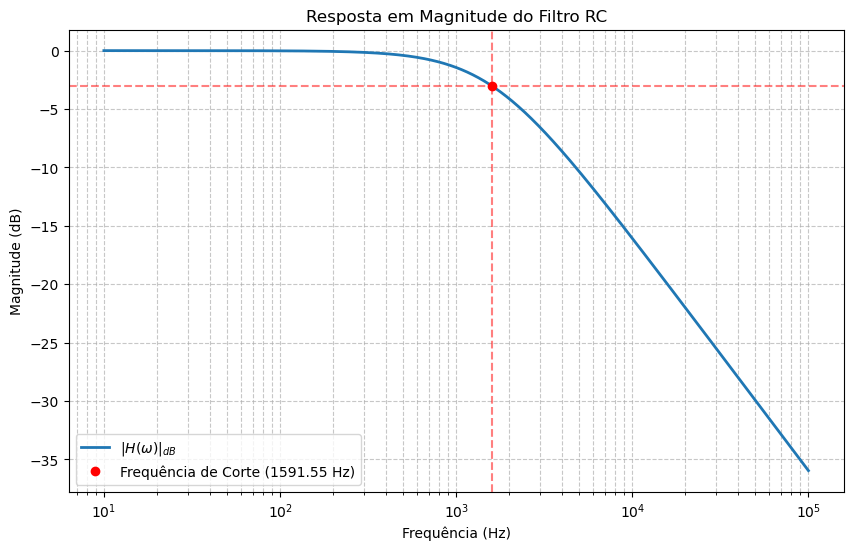

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 10e3
C = 10e-9

f = np.logspace(1, 5, 1000)

w = 2 * np.pi * f

H_dB = -10 * np.log10(1 + (w**2 * R**2 * C**2))

plt.figure(figsize=(10, 6))
plt.semilogx(f, H_dB, linewidth=2, label=r'$|H(\omega)|_{dB}$')

f_corte = 1 / (2 * np.pi * R * C)
H_corte = -10 * np.log10(1 + ((2 * np.pi * f_corte)**2 * R**2 * C**2))

plt.plot(f_corte, H_corte, 'ro', label=f'Frequência de Corte ({f_corte:.2f} Hz)')
plt.axvline(x=f_corte, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=H_corte, color='red', linestyle='--', alpha=0.5)

plt.title('Resposta em Magnitude do Filtro RC')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend()
plt.show()

**Análise do Gráfico:**
O circuito apresenta um ganho de 0 dB (sinal passa integralmente) para frequências baixas. À medida que a frequência aumenta e ultrapassa a frequência de corte (aproximadamente 1.59 kHz), o ganho cai drasticamente, atenuando o sinal em uma taxa de -20 dB por década. Esse comportamento caracteriza perfeitamente um **filtro passa-baixas**.

---

## Questão 3: Expressão para a Frequência de Corte

A frequência de corte $\omega_c$ ocorre quando a resposta em magnitude cai 3 dB em relação ao ganho máximo. O ganho máximo do nosso filtro ocorre em $\omega = 0$, onde $|H(0)|_{dB} = 0 \text{ dB}$. 

Portanto, queremos encontrar $\omega_c$ tal que:

$$-10 \log_{10}(1 + \omega_c^2 R^2 C^2) = -3$$

Dividindo ambos os lados por -10:

$$\log_{10}(1 + \omega_c^2 R^2 C^2) = 0.3$$

Elevando a base 10 de ambos os lados (sabendo que $10^{0.3} \approx 2$):

$$1 + \omega_c^2 R^2 C^2 = 2 \implies \omega_c^2 R^2 C^2 = 1$$

Isolando $\omega_c$, que representa a frequência angular de corte em rad/s:

$$\omega_c = \frac{1}{RC}$$

Como $\omega_c = 2\pi f_c$, a expressão final para a frequência de corte em Hertz (Hz) é:

$$f_c = \frac{1}{2\pi RC}$$

---

## Questão 4: Simulação no LTSpice

Para levantar a curva de resposta em magnitude e fase, o circuito do filtro passa-baixas foi montado no ambiente de simulação **LTSpice**. 

**Parâmetros utilizados:**
* Resistor ($R$): 10 k$\Omega$
* Capacitor ($C$): 10 nF
* Fonte de sinal: Análise AC (Amplitude = 1)
* Diretiva de simulação: `.ac dec 100 10 100k` (Varredura de 10 Hz a 100 kHz, 100 pontos por década).

Abaixo está o diagrama de Bode gerado pelo software. A linha contínua representa a **magnitude** (em dB, eixo esquerdo) e a linha tracejada representa a **fase** (em graus, eixo direito).

*(Nota: Certifique-se de que a imagem `simulacao_ltspice.jpeg` está na mesma pasta que este notebook para ser renderizada corretamente).*

![Gráfico de Bode gerado no LTSpice](../docs/imgs/simulacao_ltspice.jpeg)

**Observação dos Resultados:**
A simulação computacional corrobora os resultados obtidos matematicamente na Questão 2. O ganho se mantém em 0 dB em baixas frequências e começa a atenuar significativamente após a frequência de corte de aproximadamente 1.59 kHz, onde o ganho é de -3 dB e a defasagem é de -45°. À medida que a frequência aumenta, a fase tende assintoticamente a -90°.

---

## Questão 5: Filtragem de uma Soma de Senóides

Nesta simulação, aplicamos uma soma de dois sinais senoidais, sendo o primeiro com frequência de **500 Hz** e o segundo com frequência de **10 kHz**, ambos com amplitude original de **10 V**.

No circuito somador resistivo apresentado na Figura 2, considerando resistores iguais de **10 kΩ**, a tensão nodal é dada por:

$$
v_{add}(t) = \frac{v_1(t) + v_2(t)}{3}
$$

Portanto, a amplitude de cada componente após o somador resistivo cai para aproximadamente:

$$
\frac{10}{3} \approx 3{,}33\,V
$$

A seguir são apresentados os resultados obtidos experimentalmente no osciloscópio antes e depois da filtragem.

---

### (i) Forma de onda após o somador resistivo

Na saída do somador resistivo, observa-se a soma dos dois sinais senoidais. A componente de menor frequência aparece como uma senoide principal, enquanto a componente de maior frequência aparece sobreposta ao sinal.

![Forma de onda após o somador resistivo](../docs/imgs/questao5_somador.jpg)

---

### (ii) Espectro de frequências após o somador resistivo

No espectro de frequência após o somador resistivo, observa-se a presença das duas componentes principais do sinal: uma componente de baixa frequência e outra componente de alta frequência. Isso confirma que o somador resistivo combinou os dois sinais aplicados na entrada.

![Espectro de frequências após o somador resistivo](../docs/imgs/questao5_somador.jpg)

---

### (iii) Forma de onda após a filtragem

Após a passagem pelo filtro passa-baixas, a componente de alta frequência é atenuada. Com isso, a forma de onda resultante se aproxima mais de uma senoide de baixa frequência.

![Forma de onda após a filtragem](../docs/imgs/questao5_filtrado.jpg)

---

### (iv) Espectro de frequência após a filtragem

No espectro de frequência após a filtragem, observa-se que a componente de alta frequência foi reduzida significativamente, enquanto a componente de baixa frequência permaneceu predominante. Esse comportamento confirma a atuação do filtro passa-baixas.

![Espectro de frequência após a filtragem](../docs/imgs/questao5_filtrado.jpg)
